## Установка библиотек, импорты, seed и среда

In [1]:
!pip install -q transformers datasets accelerate scikit-learn matplotlib pandas

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

Device: cpu


## Загрузка данных

In [4]:
dataset = load_dataset("dair-ai/emotion", "split")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

## Первичный анализ данных

In [5]:
for split_name in dataset.keys():
    print(split_name, len(dataset[split_name]))

label_names = dataset["train"].features["label"].names
print("Classes:", label_names)
print("Num classes:", len(label_names))

train 16000
validation 2000
test 2000
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Num classes: 6


In [6]:
sample_df = pd.DataFrame(dataset["train"][:5])
sample_df["label_name"] = sample_df["label"].map(lambda x: label_names[x])
sample_df[["text", "label", "label_name"]]

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


В данной работе классифицируются тексты по эмоциональным классам:
`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.

## Токенизация

In [7]:
base_model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

In [8]:
texts_for_tokenization = dataset["train"]["text"][:3]

encoded = tokenizer(
    texts_for_tokenization,
    padding=True,
    truncation=True,
    max_length=32
)

print("CLS token:", tokenizer.cls_token, tokenizer.cls_token_id)
print("SEP token:", tokenizer.sep_token, tokenizer.sep_token_id)
print("PAD token:", tokenizer.pad_token, tokenizer.pad_token_id)
print()

for i, text in enumerate(texts_for_tokenization):
    print("=" * 80)
    print("TEXT:")
    print(text)
    print()
    print("TOKENS:")
    print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][i]))
    print()
    print("INPUT_IDS:")
    print(encoded["input_ids"][i])
    print()
    print("ATTENTION_MASK:")
    print(encoded["attention_mask"][i])
    print()

CLS token: [CLS] 101
SEP token: [SEP] 102
PAD token: [PAD] 0

TEXT:
i didnt feel humiliated

TOKENS:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

INPUT_IDS:
[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

ATTENTION_MASK:
[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

TEXT:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

TOKENS:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']

INPUT_IDS:
[101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

ATTENTION_MASK:
[1, 1, 1, 1, 1, 1, 1

In [9]:
short_text = dataset["train"]["text"][0]
long_text = max(dataset["train"]["text"][:200], key=len)

short_enc = tokenizer(short_text, padding="max_length", truncation=True, max_length=20)
long_enc_no_trunc = tokenizer(long_text)
long_enc_trunc = tokenizer(long_text, truncation=True, max_length=20)

print("Short text:")
print(short_text)
print("Length after padding to 20:", len(short_enc["input_ids"]))
print()

print("Long text:")
print(long_text)
print("Original tokenized length:", len(long_enc_no_trunc["input_ids"]))
print("After truncation to 20:", len(long_enc_trunc["input_ids"]))
print("Truncated tokens:")
print(tokenizer.convert_ids_to_tokens(long_enc_trunc["input_ids"]))

Short text:
i didnt feel humiliated
Length after padding to 20: 20

Long text:
i lost my special mind but don t worry i m still sane i just wanted you to feel what i felt while reading this book i don t know how many times it was said that sam was special but i can guarantee you it was many more times than what i used in that paragraph did i tell you she was special
Original tokenized length: 66
After truncation to 20: 20
Truncated tokens:
['[CLS]', 'i', 'lost', 'my', 'special', 'mind', 'but', 'don', 't', 'worry', 'i', 'm', 'still', 'sane', 'i', 'just', 'wanted', 'you', 'to', '[SEP]']


## Инференс готовой pretrained-модели

In [10]:
inference_model_name = "bhadresh-savani/distilbert-base-uncased-emotion"

clf_pipe = pipeline(
    "text-classification",
    model=inference_model_name,
    tokenizer=inference_model_name,
    top_k=None,
    device=0 if torch.cuda.is_available() else -1
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [11]:
inference_texts = [
    "I am so happy that everything worked out today!",
    "I feel really lonely and miserable right now.",
    "Why did this happen to me? I am furious.",
    "This is amazing, I did not expect that at all!",
    "I am scared about tomorrow's results."
]

raw_preds = clf_pipe(inference_texts)

rows = []
for text, pred_list in zip(inference_texts, raw_preds):
    best_pred = max(pred_list, key=lambda x: x["score"])
    rows.append({
        "text": text,
        "pred_label": best_pred["label"],
        "confidence": best_pred["score"]
    })

pd.DataFrame(rows)

,text,pred_label,confidence
0,I am so happy that everything worked out today!,joy,0.998586
1,I feel really lonely and miserable right now.,sadness,0.999066
2,Why did this happen to me? I am furious.,anger,0.997533
3,"This is amazing, I did not expect that at all!",surprise,0.893499
4,I am scared about tomorrow's results.,fear,0.997354


Готовая pretrained-модель показывает разумные предсказания на простых примерах и подходит для демонстрации инференса.
Однако для основной части домашнего задания далее выполняется собственный fine-tuning модели на выбранном датасете.

## Подготовка данных для fine-tuning

In [12]:
max_length = 128

def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=max_length)

tokenized_dataset = dataset.map(preprocess_function, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [13]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [14]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

id2label, label2id

({0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'},
 {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5})

## Метрики качества

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

## Fine-tuning модели

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
training_args = TrainingArguments(
    output_dir=str(ARTIFACTS_DIR / "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
    disable_tqdm=True
)

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [19]:
trainer.train()

C:\Users\deado\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.4273', 'grad_norm': '12.51', 'learning_rate': '1e-05', 'epoch': '1'}
{'eval_loss': '0.2096', 'eval_accuracy': '0.929', 'eval_f1_macro': '0.9049', 'eval_runtime': '20.63', 'eval_samples_per_second': '96.95', 'eval_steps_per_second': '12.12', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\deado\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.1573', 'grad_norm': '22.01', 'learning_rate': '5e-09', 'epoch': '2'}
{'eval_loss': '0.1744', 'eval_accuracy': '0.9395', 'eval_f1_macro': '0.9154', 'eval_runtime': '20.52', 'eval_samples_per_second': '97.48', 'eval_steps_per_second': '12.19', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '1418', 'train_samples_per_second': '22.57', 'train_steps_per_second': '2.821', 'train_loss': '0.2923', 'epoch': '2'}


TrainOutput(global_step=4000, training_loss=0.2923153991699219, metrics={'train_runtime': 1417.7404, 'train_samples_per_second': 22.571, 'train_steps_per_second': 2.821, 'train_loss': 0.2923153991699219, 'epoch': 2.0})

## Оценка качества на validation и test

In [20]:
val_output = trainer.predict(tokenized_dataset["validation"])

val_metrics = {
    "validation_loss": val_output.metrics["test_loss"],
    "validation_accuracy": val_output.metrics["test_accuracy"],
    "validation_f1_macro": val_output.metrics["test_f1_macro"],
}

val_metrics

C:\Users\deado\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'validation_loss': 0.17444999516010284,
 'validation_accuracy': 0.9395,
 'validation_f1_macro': 0.9154455157241945}

In [21]:
test_output = trainer.predict(tokenized_dataset["test"])

test_metrics = {
    "test_loss": test_output.metrics["test_loss"],
    "test_accuracy": test_output.metrics["test_accuracy"],
    "test_f1_macro": test_output.metrics["test_f1_macro"],
}

test_metrics

C:\Users\deado\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 0.22026604413986206,
 'test_accuracy': 0.923,
 'test_f1_macro': 0.877666230163297}

In [22]:
logits = test_output.predictions
y_true = test_output.label_ids
y_pred = np.argmax(logits, axis=1)

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
confidence = probs.max(axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average="macro")

print("Test accuracy:", test_accuracy)
print("Test f1_macro:", test_f1_macro)

Test accuracy: 0.923
Test f1_macro: 0.877666230163297


## Матрица ошибок

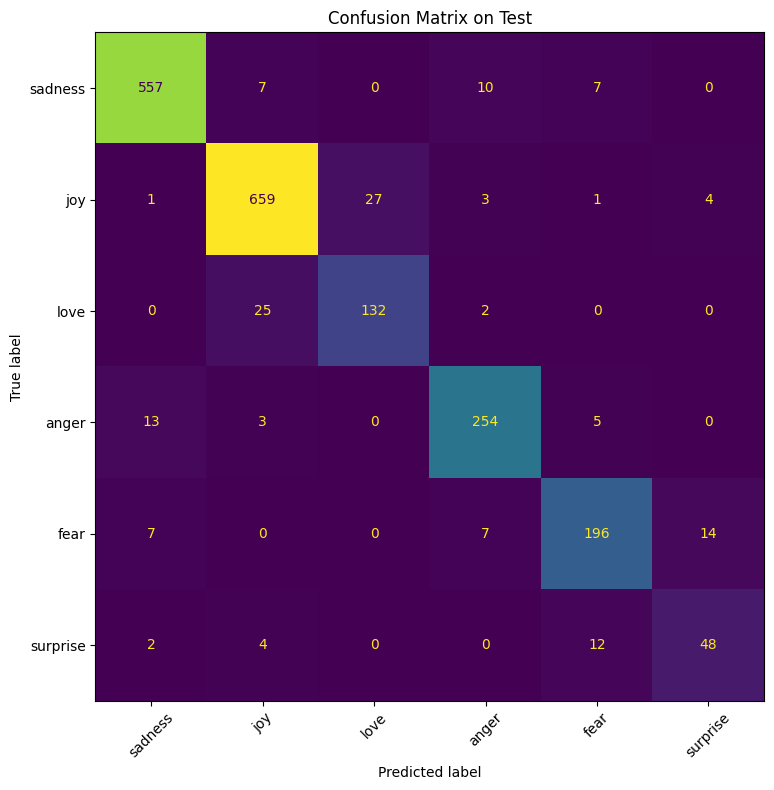

Saved to: artifacts\confusion_matrix.png


In [23]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix on Test")
plt.tight_layout()

cm_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved to:", cm_path)

## Примеры предсказаний и сохранение артефактов

In [24]:
predictions_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": [id2label[i] for i in y_true],
    "pred_label": [id2label[i] for i in y_pred],
    "confidence": confidence
})

predictions_df.head(10)

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.999466
1,im updating my blog because i feel shitty,sadness,sadness,0.999511
2,i never make her separate from me because i do...,sadness,sadness,0.999511
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.999366
4,i was feeling a little vain when i did this one,sadness,sadness,0.999493
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.998782
6,i felt anger when at the end of a telephone call,anger,anger,0.997793
7,i explain why i clung to a relationship with a...,joy,joy,0.838349
8,i like to have the same breathless feeling as ...,joy,joy,0.999400
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.998900


In [25]:
sample_predictions_df = predictions_df.sample(n=50, random_state=SEED).reset_index(drop=True)

sample_csv_path = ARTIFACTS_DIR / "sample_predictions.csv"
sample_predictions_df.to_csv(sample_csv_path, index=False)

print("Saved to:", sample_csv_path)
sample_predictions_df.head(10)

Saved to: artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,i feel so dirty but after spending a day at th...,sadness,sadness,0.999354
1,i could feel his breath on me and smell the sw...,joy,love,0.931551
2,i just want to feel loved by you,love,love,0.993385
3,i have felt the need to write out my sometimes...,anger,anger,0.972123
4,at a party i met a girl who drew me to her,anger,fear,0.660141
5,i feel this strange sort of liberation,surprise,fear,0.778383
6,i remember feeling thrilled to use my nursing ...,joy,joy,0.999450
7,i always feel sympathetic for those that do as...,love,love,0.996132
8,i feel a little stunned but can t imagine what...,surprise,surprise,0.993628
9,i feel slytherin is my house slytherin is for ...,joy,joy,0.948973


## Анализ ошибок

In [26]:
errors_df = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

errors_df.head(10)

,text,true_label,pred_label,confidence
1533,i actually was in a meeting last week where so...,anger,sadness,0.999271
1253,i don t feel betrayed coz the backstabber had ...,surprise,sadness,0.999256
585,i grabbed my dog and hugged her fiercly for th...,fear,sadness,0.999215
816,whenever i put myself in others shoes and try ...,anger,joy,0.999167
1146,i feel affirmed gracious sensuous and will hav...,love,joy,0.999131
1627,i feel i can only hope im not alone in these t...,sadness,joy,0.998394
426,i feel unprotected a class post count link hre...,sadness,fear,0.997581
1188,i felt confused me sometimes that makes me fee...,sadness,fear,0.997525
1020,i know is that she s here and i m so thankful ...,sadness,joy,0.997431
1837,i hate these feelings in my heart i hate that ...,sadness,anger,0.997241


Модель чаще ошибается на коротких и неоднозначных текстах, где эмоция выражена неявно.
Также встречаются ошибки между близкими по смыслу классами, например `sadness`, `fear` и `surprise`.
Часть примеров можно считать пограничными, так как в них присутствуют смешанные эмоциональные оттенки.